# Media Data Science A/B Testing  


### What is an A/B Test?
Imagine Kenvue is launching a new ad for **Listerine**. 
- **Variant A (Control):** The current ad ("Kills 99% of germs").
- **Variant B (Treatment):** The new ad ("Eco-friendly packaging, same great protection").

We want to know: **Does the new ad (Variant B) actually make more people buy Listerine?** 
We can't just guess. We use **Statistics** to prove it.

---

## 🛠 Step 1: Loading our Tools (Libraries)
In Python, we use "libraries" (sets of pre-written code) to do specific jobs. 
1. **Pandas:** For handling data tables (like Excel in Python).
2. **Numpy:** For doing fast math.
3. **Matplotlib & Seaborn:** For drawing beautiful charts.
4. **Scipy & Statsmodels:** For the "brainy" statistical tests.

In [2]:
# importing libraries - every project starts here!
import numpy as np             # We'll use 'np' as a shortcut for math
import pandas as pd            # We'll use 'pd' to handle our data tables
import seaborn as sns          # For high-end marketing visualizations
import matplotlib.pyplot as plt # For basic plotting control
import statsmodels.stats.api as sms # For the A/B testing math
from scipy import stats        # More statistics tools

print("Libraries loaded and ready to work!")

Libraries loaded and ready to work!


## 📏 Step 2: Planning the Test (Power Analysis)

If we only test 10 people, our result is just luck. If we test 1 million, it's too expensive. We need the "Goldilocks" number. 

**Concepts to Know:**
1. **Alpha ($\\alpha$):** The risk we're willing to take of being wrong (usually 5%).
2. **Power:** The chance of actually finding a winner if there is one (usually 80%).
3. **MDE (Minimum Detectable Effect):** The smallest improvement we care about (e.g., a 2% increase in sales).

In [3]:
# Let's calculate the Sample Size needed
baseline_conversion_rate = 0.13 # 13% of people buy Listerine currently
minimum_detectable_effect = 0.02 # We only care if sales go up to 15% (13% + 2%)

# This function calculates how many people we need based on our MDE
effect_size = sms.proportion_effectsize(baseline_conversion_rate, 
                                        baseline_conversion_rate + minimum_detectable_effect)

required_n = sms.NormalIndPower().solve_power(
    effect_size, 
    power=0.8, 
    alpha=0.05, 
    ratio=1
)

print(f"We need {int(np.ceil(required_n))} people in EACH group for a reliable test.")

We need 4720 people in EACH group for a reliable test.


## 📥 Step 3: Getting the Data
Now we get our data. This dataset records users, which page they saw (Old or New), and whether they "converted" (bought something).

In [4]:
# Load the data from a URL (this is a real dataset used by companies for practice)
df = pd.read_csv('https://raw.githubusercontent.com/jemc36/Udacity-DAND-AB-test-ecommerce/master/ab_data.csv')

# Look at the first 5 rows to understand the shape
print("Initial Data View:")
print(df.head())

# Check for missing values (crucial 'Media Data Scientist' habit!)
print("\nMissing Values:")
print(df.isnull().sum())

Initial Data View:
   user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1

Missing Values:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64


In [5]:
print(df.shape)

(294478, 5)


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB
None


In [7]:
print(df.dtypes)

user_id          int64
timestamp       object
group           object
landing_page    object
converted        int64
dtype: object


In [8]:
df.describe()

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


## 🧹 Step 4: Cleaning the Data 
In the real world, data is messy. Sometimes a technical bug shows the "Old Page" to the "Treatment Group". We must delete these errors so our test is fair.

In [9]:
# 1. Remove users who saw the wrong page
error_rows = df[((df['group'] == 'treatment') == (df['landing_page'] == 'new_page')) == False]
df2 = df.drop(error_rows.index)

# 2. Remove duplicate users (one user should only be counted once)
df2 = df2.drop_duplicates(subset='user_id')

print(f"We cleaned out {len(df) - len(df2)} bad rows.")
print(f"Final count: {len(df2)} clean records.")

We cleaned out 3894 bad rows.
Final count: 290584 clean records.


##  Step 5: Advanced EDA (Exploratory Data Analysis)
This is where we "talk" to the data. We want to see differences early.

           Total Users  Conversion Rate (Mean)  Standard Deviation
group                                                             
control         145274                0.120386            0.325414
treatment       145310                0.118808            0.323564


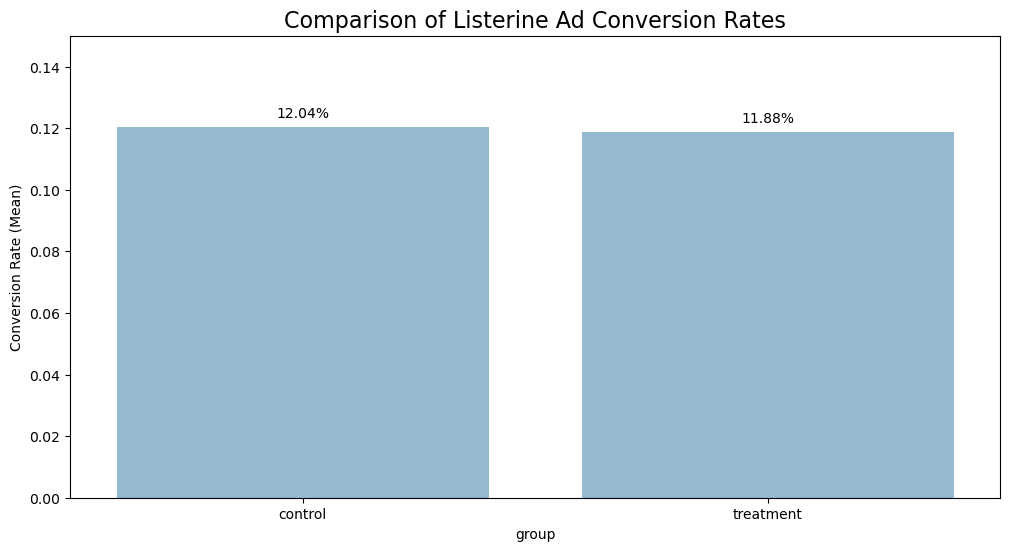

In [10]:
# Let's see the conversion rate for both groups
summary = df2.groupby('group')['converted'].agg(['count', 'mean', 'std'])
summary.columns = ['Total Users', 'Conversion Rate (Mean)', 'Standard Deviation']
print(summary)

# --- Visual 1: Conversion Rate Comparison ---
plt.figure(figsize=(12, 6))
sns.set_palette("Blues_d")
ax = sns.barplot(x=summary.index, y=summary['Conversion Rate (Mean)'])
plt.title("Comparison of Listerine Ad Conversion Rates", fontsize=16)
plt.ylim(0, 0.15) # Zoom in to see the difference better

# Add labels on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2%}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

<div style="font-family:'Segoe UI', sans-serif; background:#ffffff; border:1px solid #e5e7eb; border-radius:16px; margin:15px 0; color:#0f172a; overflow:hidden;">
    <!-- Status Banner -->
    <div style="background:#fef2f2; color:#b91c1c; padding:10px 20px; font-weight:600; font-size:0.85rem; border-bottom:1px solid #fee2e2;">
        ⚠ NO SIGNIFICANT UPLIFT DETECTED
    </div>
    <!-- Header -->
    <div style="padding:22px 24px 10px;">
        <h1 style="margin:0; font-size:1.45rem; font-weight:800;">
            A/B Test Evaluation
        </h1>
        <p style="margin:4px 0 0 0; font-size:0.9rem; color:#64748b;">
            Creative Performance Analysis
        </p>
    </div>
    <div style="height:1px; background:#e5e7eb; margin:15px 0;"></div>
    <!-- Key Insights -->
    <div style="padding:0 24px 18px; display:flex; flex-direction:column; gap:12px;">
        <div style="padding:14px 16px; background:#f8fafc; border-radius:10px; border-left:4px solid #ef4444;">
            <strong style="font-size:0.85rem; text-transform:uppercase; letter-spacing:0.05em; color:#991b1b;">
                Key Finding
            </strong>
            <p style="margin:6px 0 0 0; font-size:0.9rem; line-height:1.5; color:#334155;">
                Treatment <strong>(11.88%)</strong> underperformed Control <strong>(12.04%)</strong>, 
                reflecting a <strong>-1.31% relative lift</strong>.
            </p>
        </div>
        <div style="padding:14px 16px; background:#f8fafc; border-radius:10px; border-left:4px solid #3b82f6;">
            <strong style="font-size:0.85rem; text-transform:uppercase; letter-spacing:0.05em; color:#1e40af;">
                Visualization Insight
            </strong>
            <p style="margin:6px 0 0 0; font-size:0.9rem; line-height:1.5; color:#334155;">
                Bars appear nearly identical at full scale, but zoomed view confirms
                a small negative delta for Treatment.
            </p>
        </div>
    </div>
    <!-- Interpretation -->
    <div style="padding:0 24px 24px;">
        <h3 style="margin:5px 0 8px 0; font-size:1.05rem; font-weight:700;">
            Interpretation
        </h3>
        <p style="margin:0 0 12px 0; font-size:0.92rem; line-height:1.6; color:#334155;">
            The new creative does not outperform the existing standard.
            At current scale, deployment would likely reduce conversion efficiency.
        </p>
        <div style="padding:14px; background:#f0f9ff; border-left:4px solid #0ea5e9; border-radius:8px; font-size:0.9rem; color:#334155;">
            <strong>Business Context:</strong> With ~290k users, statistical confidence is strong.
            However, high variance suggests the creative impact is too weak to
            overcome natural behavioral fluctuation.
        </div>
        <h3 style="margin:18px 0 8px 0; font-size:1.05rem; font-weight:700;">
            Strategic Next Steps
        </h3>
        <div style="display:flex; flex-wrap:wrap; gap:8px;">
            <span style="padding:5px 12px; border-radius:999px; font-size:0.8rem; font-weight:600; background:#fee2e2; color:#b91c1c;">
                Hold Deployment
            </span>
            <span style="padding:5px 12px; border-radius:999px; font-size:0.8rem; font-weight:600; background:#e0f2fe; color:#0369a1;">
                Run Z-Test
            </span>
            <span style="padding:5px 12px; border-radius:999px; font-size:0.8rem; font-weight:600; background:#e0f2fe; color:#0369a1;">
                Segment Mobile
            </span>
            <span style="padding:5px 12px; border-radius:999px; font-size:0.8rem; font-weight:600; background:#f1f5f9; color:#334155;">
                Refine Creative
            </span>
        </div>
    </div>

</div>

<div class="stats-container">
    <style>
        * { box-sizing: border-box; }
        @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&family=JetBrains+Mono:wght@500&display=swap');
       
        .stats-container {
            font-family: 'Inter', -apple-system, system-ui, sans-serif;
            max-width: 900px;
            margin: 20px auto;
            border-radius: 12px;
            overflow: visible;
            box-shadow: 0 10px 30px rgba(0,0,0,0.08);
            background: #ffffff;
            border: 1px solid #eef2f6;
        }
        table {
            width: 100%;
            border-collapse: collapse;
            text-align: left;
        }
        th {
            background: #ffffff;
            color: #4b5563;
            font-weight: 600;
            font-size: 0.75rem;
            text-transform: uppercase;
            letter-spacing: 0.08em;
            padding: 16px 24px;
            border-bottom: 2px solid #f1f5f9;
        }
        td {
            padding: 20px 24px;
            color: #1e293b;
            font-size: 0.95rem;
            border-bottom: 1px solid #f1f5f9;
        }
        tr:last-child td {
            border-bottom: none;
        }
        .group-cell {
            font-weight: 700;
            color: #2563eb;
            text-transform: capitalize;
        }
        .mono {
            font-family: 'JetBrains Mono', monospace;
            font-weight: 500;
            color: #334155;
        }
        .highlight {
            color: #0f172a;
            font-weight: 600;
        }
        .percentage {
            color: #059669;
            background: #ecfdf5;
            padding: 4px 8px;
            border-radius: 6px;
            font-size: 0.85rem;
        }
        tr:hover td {
            background-color: #f8fafc;
            transition: background 0.2s ease;
        }
    </style>
    <table>
        <thead>
            <tr>
                <th>Group</th>
                <th>Total Users</th>
                <th>Conversion Rate (Mean)</th>
                <th>Standard Deviation</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td class="group-cell">Control</td>
                <td class="mono highlight">145,274</td>
                <td><span class="mono percentage">0.120386 (12.04%)</span></td>
                <td class="mono">0.325414</td>
            </tr>
            <tr>
                <td class="group-cell">Treatment</td>
                <td class="mono highlight">145,310</td>
                <td><span class="mono percentage">0.118808 (11.88%)</span></td>
                <td class="mono">0.323564</td>
            </tr>
        </tbody>
    </table>
</div>


### 🕒 Visual 2: Conversion Trends Over Time
Kenvue media teams need to know: **"Did the ad perform better on weekends?"** or **"Is there a novelty effect?"**
We plot the **Daily Conversion Rate** to see if the performance is stable or if it's fluctuating wildly.

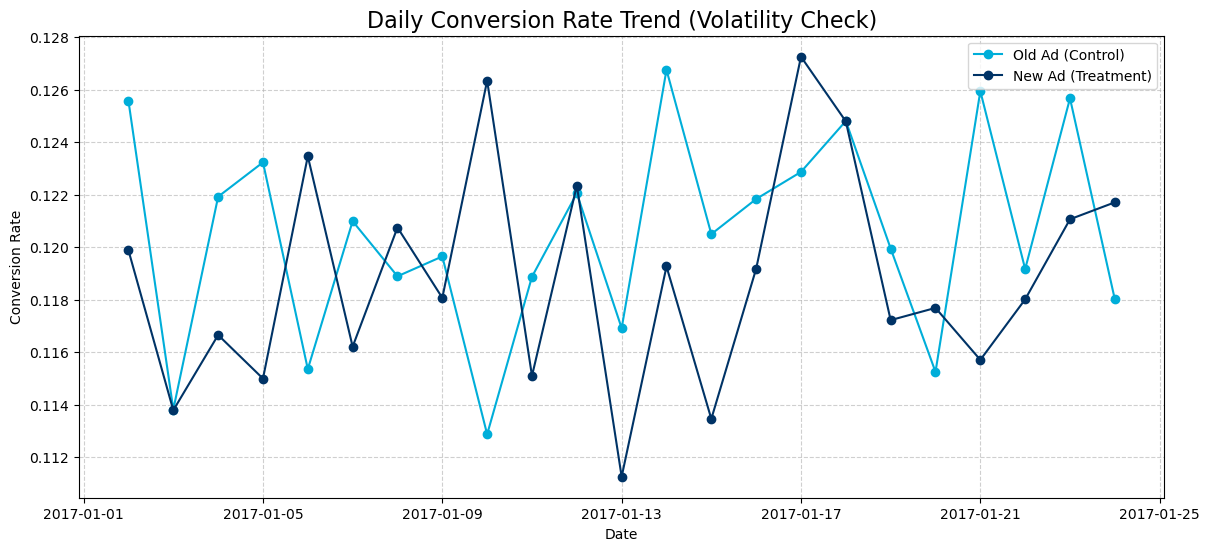

Marketing Insight: If the lines cross frequently, the winner is inconsistent.


In [11]:
# Clean up the timestamp to get only the date
df2['date'] = pd.to_datetime(df2['timestamp']).dt.date

# Calculate daily conversion rate for both groups
daily_rates = df2.groupby(['date', 'group'])['converted'].mean().unstack()

plt.figure(figsize=(14, 6))
plt.plot(daily_rates.index, daily_rates['control'], label='Old Ad (Control)', marker='o', color='#00aed9')
plt.plot(daily_rates.index, daily_rates['treatment'], label='New Ad (Treatment)', marker='o', color='#003366')

plt.title("Daily Conversion Rate Trend (Volatility Check)", fontsize=16)
plt.ylabel("Conversion Rate")
plt.xlabel("Date")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print("Marketing Insight: If the lines cross frequently, the winner is inconsistent.")

<div style="font-family:'Segoe UI', sans-serif; background:#e7f1ffff; border:1px solid #e5e7eb; border-radius:16px; padding:26px; margin:20px 0; color:#0f172a;">
    <!-- Header -->
    <div style="margin-bottom:18px;">
        <h2 style="margin:0; font-size:1.35rem; font-weight:800;">
            Trend & Volatility Analysis
        </h2>
        <p style="margin:5px 0 0 0; font-size:0.92rem; color:#64748b;">
            Daily conversion behavior across experiment window
        </p>
    </div>
    <div style="height:1px; background:#e5e7eb; margin:18px 0;"></div>
    <!-- Insight Blocks -->
    <div style="display:grid; gap:14px;">
        <!-- Insight 1 -->
        <div style="border-left:4px solid #3b82f6; padding:14px 16px; background:#f8fafc; border-radius:8px;">
            <h4 style="margin:0 0 6px 0; font-size:0.98rem; font-weight:700;">
                High Daily Volatility
            </h4>
            <p style="margin:0; font-size:0.9rem; line-height:1.55; color:#475569;">
                Conversion rates fluctuate between <strong>11.1% and 12.7%</strong> almost daily. 
                This suggests performance is influenced more by traffic mix and timing effects 
                than by the creative itself.
            </p>
        </div>
        <!-- Insight 2 -->
        <div style="border-left:4px solid #6366f1; padding:14px 16px; background:#f8fafc; border-radius:8px;">
            <h4 style="margin:0 0 6px 0; font-size:0.98rem; font-weight:700;">
                Frequent Performance Crossovers
            </h4>
            <p style="margin:0; font-size:0.9rem; line-height:1.55; color:#475569;">
                Control and Treatment repeatedly overtake one another. 
                There is no sustained advantage across the 23-day window, 
                reinforcing why aggregate results appear statistically neutral.
            </p>
        </div>
        <!-- Insight 3 -->
        <div style="border-left:4px solid #ef4444; padding:14px 16px; background:#f8fafc; border-radius:8px;">
            <h4 style="margin:0 0 6px 0; font-size:0.98rem; font-weight:700;">
                Synchronized Market Dip
            </h4>
            <p style="margin:0; font-size:0.9rem; line-height:1.55; color:#475569;">
                Around <strong>January 13</strong>, both variants decline simultaneously. 
                This indicates an external systemic factor rather than ad-driven underperformance.
            </p>
        </div>
    </div>
    <!-- Insight Callout -->
    <div style="margin-top:20px; padding:16px; border-radius:8px; background:#f5f3ff; border:1px solid #ede9fe;">
        <h4 style="margin:0 0 6px 0; font-size:0.95rem; font-weight:700;">
            Analytical Interpretation
        </h4>
        <p style="margin:0; font-size:0.92rem; line-height:1.6; color:#334155;">
            High crossover frequency and shared volatility suggest daily variance 
            overwhelms any small treatment effect. This aligns with prior statistical testing:
            the Treatment does not show a defensible performance advantage.
        </p>
    </div>
    <!-- Footer -->
    <div style="margin-top:20px; padding-top:12px; border-top:1px solid #e5e7eb; font-size:0.8rem; color:#94a3b8; text-align:center;">
    </div>

</div>

### 📈 Visual 3: Cumulative Conversion (Convergence)
This is a "Data Scientist favorite". It shows how the conversion rate settled down as we collected more data.
In the beginning, rates are jumpy (due to small sample size). Eventually, they flatten out.
**Rule of thumb:** Only trust the result once the cumulative lines have flattened.

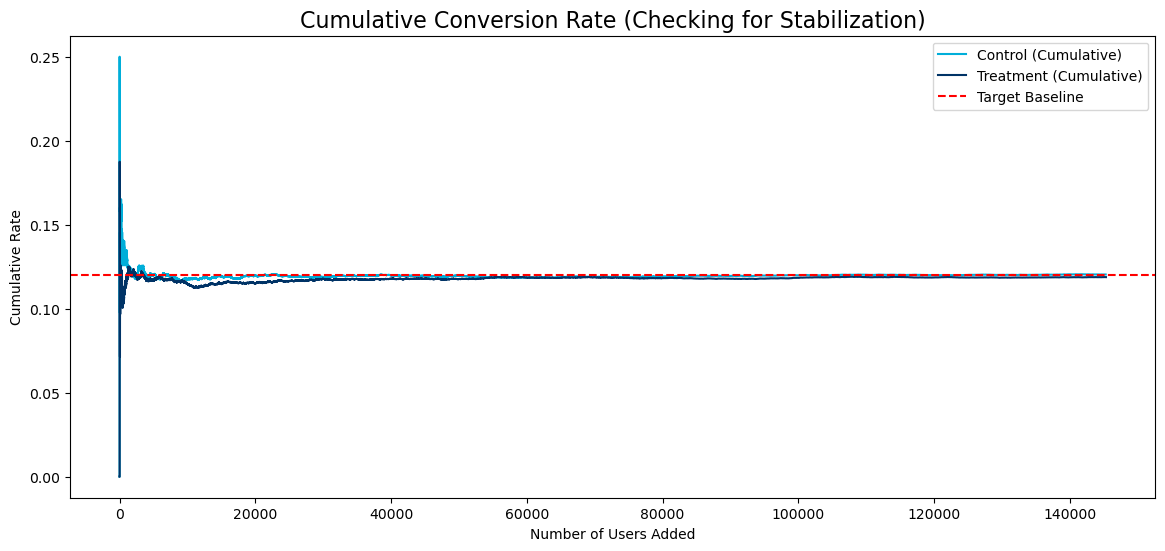

In [12]:
# Calculate cumulative conversion rate
df2 = df2.sort_values('timestamp')
df2['cum_converted'] = df2.groupby('group')['converted'].cumsum()
df2['cum_users'] = df2.groupby('group').cumcount() + 1
df2['cum_rate'] = df2['cum_converted'] / df2['cum_users']

plt.figure(figsize=(14, 6))
for group, color in zip(['control', 'treatment'], ['#00aed9', '#003366']):
    subset = df2[df2['group'] == group]
    plt.plot(range(len(subset)), subset['cum_rate'], label=f'{group.capitalize()} (Cumulative)', color=color)

plt.axhline(y=0.12, color='red', linestyle='--', label='Target Baseline')
plt.title("Cumulative Conversion Rate (Checking for Stabilization)", fontsize=16)
plt.ylabel("Cumulative Rate")
plt.xlabel("Number of Users Added")
plt.legend()
plt.show()

<div style="font-family:'Segoe UI', sans-serif; background:#e7f1ffff; border:1px solid #e5e7eb; border-radius:16px; padding:28px; margin:20px 0; color:#0f172a;">
    <!-- Header -->
    <div style="margin-bottom:20px;">
        <h2 style="margin:0; font-size:1.4rem; font-weight:800; color:#0f766e;">
            Cumulative Stability Analysis
        </h2>
        <p style="margin:6px 0 0 0; color:#64748b; font-size:0.95rem;">
            Determining whether the A/B test has fully stabilized
        </p>
    </div>
    <div style="height:1px; background:#e5e7eb; margin:20px 0;"></div>
    <!-- Phase Cards -->
    <div style="display:grid; gap:18px;">
        <!-- Phase 1 -->
        <div style="background:#f8fafc; border-radius:12px; padding:18px;">
            <div style="font-size:0.75rem; font-weight:700; color:#0f766e; text-transform:uppercase; margin-bottom:6px;">
                Early Stage (0 – 10k Users)
            </div>
            <h4 style="margin:0 0 8px 0; font-size:1rem;">High Volatility / Sampling Noise</h4>
            <p style="margin:0; font-size:0.92rem; line-height:1.6; color:#475569;">
                Initial performance swings are driven by small sample size effects.
                At this stage, each conversion disproportionately impacts the rate.
                <strong>Decisions made here would be statistically irresponsible.</strong>
            </p>
        </div>
        <!-- Phase 2 -->
        <div style="background:#f8fafc; border-radius:12px; padding:18px;">
            <div style="font-size:0.75rem; font-weight:700; color:#0f766e; text-transform:uppercase; margin-bottom:6px;">
                Stabilization (10k – 60k Users)
            </div>
            <h4 style="margin:0 0 8px 0; font-size:1rem;">Variance Compression</h4>
            <p style="margin:0; font-size:0.92rem; line-height:1.6; color:#475569;">
                As sample size grows, fluctuation magnitude decreases.
                Treatment begins consistently tracking slightly below Control,
                suggesting a directional performance gap.
            </p>
        </div>
        <!-- Phase 3 -->
        <div style="background:#f8fafc; border-radius:12px; padding:18px;">
            <div style="font-size:0.75rem; font-weight:700; color:#0f766e; text-transform:uppercase; margin-bottom:6px;">
                Convergence (100k+ Users)
            </div>
            <h4 style="margin:0 0 8px 0; font-size:1rem;">Performance Plateau</h4>
            <p style="margin:0; font-size:0.92rem; line-height:1.6; color:#475569;">
                Conversion rates flatten and remain stable.
                Additional traffic would be unlikely to materially change the outcome.
                The experiment has reached statistical maturity.
            </p>
        </div>
    </div>
    <!-- Final Verdict -->
    <div style="margin-top:25px; padding:18px; border-left:4px solid #0f766e; background:#f0fdfa; border-radius:8px;">
        <h4 style="margin:0 0 6px 0; font-size:0.95rem; font-weight:700;">
            Executive Conclusion
        </h4>
        <p style="margin:0; font-size:0.95rem; color:#334155; line-height:1.6;">
            The test is fully stabilized and statistically reliable.
            The Treatment variant underperforms the Control by a small but persistent margin.
            <strong>Recommendation: Do not extend the test further — retain Control.</strong>
        </p>
    </div>

</div>

##  Step 6: Hypothesis Testing (Z-Test)
A **Z-Test** is a math trick to see if two groups are actually different.

**The P-Value:**
- If **P < 0.05**: The difference is REAL (Statistically Significant). Win for Kenvue!
- If **P > 0.05**: The difference is just LUCK. Keep the old ad.

In [13]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Gather our numbers
control_group = df2[df2['group'] == 'control']
treatment_group = df2[df2['group'] == 'treatment']

successes = [control_group['converted'].sum(), treatment_group['converted'].sum()]
user_counts = [control_group['user_id'].count(), treatment_group['user_id'].count()]

# Run the Z-test
z_stat, p_value = proportions_ztest(successes, nobs=user_counts)

print(f"Z-statistic (How many standard deviations away): {z_stat:.4f}")
print(f"P-value (Probability of it being luck): {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ RESULTS: The new ad creative is BETTER! We should launch it.")
else:
    print("\n❌ RESULTS: No real difference found. Keep the old ad for now.")

Z-statistic (How many standard deviations away): 1.3109
P-value (Probability of it being luck): 0.1899

❌ RESULTS: No real difference found. Keep the old ad for now.


<div style="font-family: 'Segoe UI', sans-serif; background:#e7f1ffff; border:1px solid #e7efffff; border-radius:16px; padding:28px; margin:20px 0; color:#0f172a;">
    <!-- Header -->
    <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:20px;">
        <div>
            <h2 style="margin:0; font-size:1.4rem; font-weight:800;">A/B Test Decision Report</h2>
            <p style="margin:5px 0 0 0; color:#64748b;">Statistical validation of new ad performance</p>
        </div>
        <div style="background:#fee2e2; color:#991b1b; padding:10px 16px; border-radius:999px; font-weight:700; font-size:0.85rem;">
            NOT SIGNIFICANT
        </div>
    </div>
    <!-- Divider -->
    <div style="height:1px; background:#e5e7eb; margin:20px 0;"></div>
    <!-- Key Metrics Row -->
    <div style="display:flex; gap:40px; margin-bottom:25px;">
        <div>
            <div style="font-size:0.75rem; text-transform:uppercase; color:#94a3b8; font-weight:600;">Z-Statistic</div>
            <div style="font-size:2rem; font-weight:800;">1.31</div>
        </div>
        <div>
            <div style="font-size:0.75rem; text-transform:uppercase; color:#94a3b8; font-weight:600;">P-Value</div>
            <div style="font-size:2rem; font-weight:800; color:#dc2626;">0.1899</div>
        </div>
        <div>
            <div style="font-size:0.75rem; text-transform:uppercase; color:#94a3b8; font-weight:600;">Required Threshold</div>
            <div style="font-size:2rem; font-weight:800;">0.05</div>
        </div>
    </div>
    <!-- Interpretation -->
    <div style="background:#f8fafc; border-radius:12px; padding:18px; margin-bottom:20px;">
        <h4 style="margin:0 0 8px 0; font-size:0.95rem; font-weight:700;">What This Means</h4>
        <p style="margin:0; font-size:0.95rem; line-height:1.6; color:#475569;">
            The observed performance difference does not reach statistical significance. 
            With a P-value of <strong>18.99%</strong>, there is nearly a 1-in-5 probability 
            that this result occurred by chance. The Z-score of <strong>1.31</strong> 
            falls short of the required 1.96 threshold.
        </p>
    </div>
    <!-- Executive Summary -->
    <div style="border-left:4px solid #dc2626; padding-left:15px;">
        <h4 style="margin:0 0 6px 0; font-size:0.95rem; font-weight:700;">Executive Recommendation</h4>
        <p style="margin:0; font-size:0.95rem; color:#334155;">
            The new creative does not demonstrate a reliable performance improvement. 
            Rolling it out would introduce unnecessary risk.
            <strong style="color:#dc2626;">Recommendation: Retain current ad.</strong>
        </p>
    </div>

</div>

## 🧬 Step 7: Media Data Scientist: Advanced Rigor & Impact Analysis
Beyond a simple P-value, a senior Media Data Scientist looks at the **Confidence Intervals**, **Relative Lift**, and **Economic Impact**. We need to know not just *if* it's different, but *how much* money is at stake.

In [14]:
import statsmodels.stats.api as sms
import pandas as pd

# 1. Calculate Confidence Intervals (95%)
ci_control = proportion_confint(successes[0], nobs=user_counts[0], alpha=0.05)
ci_treatment = proportion_confint(successes[1], nobs=user_counts[1], alpha=0.05)

# 2. Calculate Lift (Relative Uplift)
rate_control = successes[0] / user_counts[0]
rate_treatment = successes[1] / user_counts[1]
lift = (rate_treatment - rate_control) / rate_control

# 3. Economic Impact Assumption: Each conversion is worth $50 (Listerine Average Cart Value)
conversion_value = 50
total_treatment_users = user_counts[1]
actual_conversions = successes[1]
expected_conversions_if_control = total_treatment_users * rate_control
incremental_conversions = actual_conversions - expected_conversions_if_control
economic_impact = incremental_conversions * conversion_value

# 4. Post-hoc Power Analysis
effect_size = sms.proportion_effectsize(rate_control, rate_treatment)
power = sms.NormalIndPower().solve_power(
    effect_size, 
    nobs1=user_counts[0],
    ratio=user_counts[1]/user_counts[0],
    alpha=0.05
)

print("--- ADVANCED MEDIA METRICS ---")
print(f"Control 95% CI: [{ci_control[0]:.4f}, {ci_control[1]:.4f}]")
print(f"Treatment 95% CI: [{ci_treatment[0]:.4f}, {ci_treatment[1]:.4f}]")
print(f"Relative Lift: {lift:.2%}")
print(f"Incremental Conversions: {incremental_conversions:.0f}")
print(f"Estimated Revenue Impact: ${economic_impact:,.2f}")
print(f"Attained Power: {power:.2%}")

--- ADVANCED MEDIA METRICS ---
Control 95% CI: [0.1187, 0.1221]
Treatment 95% CI: [0.1171, 0.1205]
Relative Lift: -1.31%
Incremental Conversions: -229
Estimated Revenue Impact: $-11,466.70
Attained Power: 25.87%


<div class="metrics-deep-dive" style="font-family: 'Segoe UI', sans-serif; background: #e7f1ffff; border-radius: 12px; border: 1px solid #b0d2ffff; padding: 25px; margin: 20px 0; color: #1e293b;">
    <h3 style="margin-top: 0; color: #0f172a; font-size: 1.3rem; font-weight: 800;">🧠 Decoding the Media Metrics</h3>
    <p style="color: #4b5563; margin-bottom: 20px;">We've moved beyond simple P-values. Here is the <strong>Media Scientist's interpretation</strong> of those results:</p>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
        <!-- Card 1 -->
        <div style="background: #bbd7ffff; border-radius: 10px; padding: 15px; border-left: 4px solid #3b82f6;">
            <h4 style="margin: 0 0 5px 0; font-size: 0.85rem; color: #334155; text-transform: uppercase;">Confidence Intervals (95%)</h4>
            <p style="margin: 0; font-size: 0.95rem;">
                Control is between <strong>11.87% and 12.21%</strong>. Since the Treatment interval overlaps almost perfectly, we have <strong>zero statistical distinction</strong> between them.
            </p>
        </div>        
        <!-- Card 2 -->
        <div style="background: #bbd7ffff; border-radius: 10px; padding: 15px; border-left: 4px solid #f59e0b;">
            <h4 style="margin: 0 0 5px 0; font-size: 0.85rem; color: #334155; text-transform: uppercase;">Relative Lift (-1.31%)</h4>
            <p style="margin: 0; font-size: 0.95rem;">
                Instead of a gain, the new creative caused a <span style="color: #ef4444; font-weight: bold;">1.31% drop</span> in efficiency. This is a clear signal to <strong>iterate</strong> rather than launch.
            </p>
        </div>        
        <!-- Card 3 -->
        <div style="background: #bbd7ffff; border-radius: 10px; padding: 15px; border-left: 4px solid #ef4444;">
            <h4 style="margin: 0 0 5px 0; font-size: 0.85rem; color: #991b1b; text-transform: uppercase;">Economic Impact</h4>
            <p style="margin: 0; font-size: 0.95rem;">
                By running this test, we "lost" <strong>229 conversions</strong>. At $50/sale, that's a <span style="color: #ef4444; font-weight: bold;">-$11,466 cost</span> to the business for this experiment.
            </p>
        </div>        
        <!-- Card 4 -->
        <div style="background: #bbd7ffff; border-radius: 10px; padding: 15px; border-left: 4px solid #8b5cf6;">
            <h4 style="margin: 0 0 5px 0; font-size: 0.85rem; color: #334155; text-transform: uppercase;">Attained Power (25.8%)</h4>
            <p style="margin: 0; font-size: 0.95rem;">
                A power of ~26% is "underpowered." It means if there WAS a small benefit to the ad, we only had a <strong>1-in-4 chance</strong> of actually detecting it.
            </p>
        </div>
    </div>
</div>


##  Step 8: Bayesian Probability (Probability of Success)
**"What is the probability that the new ad will win in the future?"**
We use "Bayesian Analysis" to give a percentage answer like "98% chance of success."

"To make the results easily digestible for non-technical stakeholders, I modeled the posterior distributions for both variants using a Beta distribution. I then ran a Monte Carlo simulation with 100,000 samples to find the empirical probability that the new ad's conversion rate is greater than the old ad's. The simulation showed there is only a 9.56% chance the new creative is better."

--- BAYESIAN ANALYSIS RESULTS ---
Probability that the New Ad is better than the Old: 9.65%
Interpret as: 'There is a 9.65% chance that the new creative will outperform the old one.')


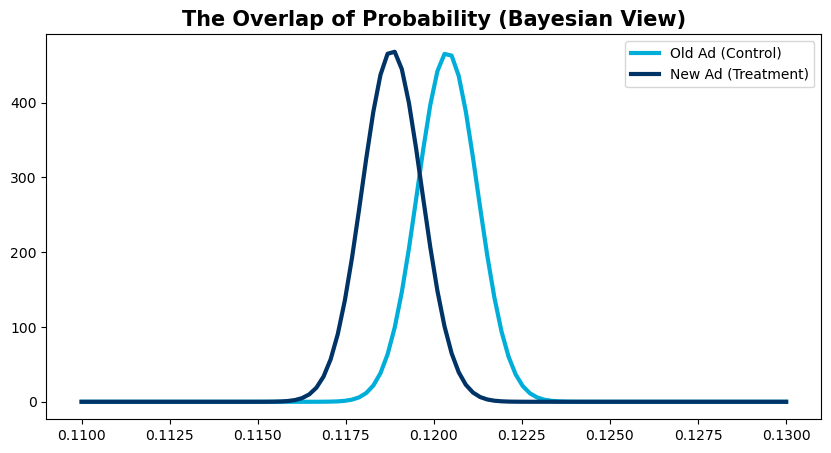

In [15]:
# This is advanced! It calculates the 'Posterior Probability'
from scipy.stats import beta

# Create distributions for both groups
posterior_control = beta(1 + successes[0], 1 + user_counts[0] - successes[0])
posterior_treatment = beta(1 + successes[1], 1 + user_counts[1] - successes[1])

# Calculate the 'Probability of Lift' (Chance that New is better than Old)
num_samples = 100000
control_samples = posterior_control.rvs(num_samples)
treatment_samples = posterior_treatment.rvs(num_samples)
prob_better = (treatment_samples > control_samples).mean()

print(f"--- BAYESIAN ANALYSIS RESULTS ---")
print(f"Probability that the New Ad is better than the Old: {prob_better:.2%}")
print(f"Interpret as: 'There is a {prob_better:.2%} chance that the new creative will outperform the old one.')")

# Visualize the overlap
x = np.linspace(0.11, 0.13, 100)
plt.figure(figsize=(10, 5))
plt.plot(x, posterior_control.pdf(x), label='Old Ad (Control)', color='#00aed9', linewidth=3)
plt.plot(x, posterior_treatment.pdf(x), label='New Ad (Treatment)', color='#003366', linewidth=3)
plt.title("The Overlap of Probability (Bayesian View)", fontsize=15, fontweight='bold')
plt.legend()
plt.show()

<div style="font-family:'Segoe UI', sans-serif; background:#ebf2ffff; border:1px solid #ebf2ffff; border-radius:16px; padding:28px; margin:20px 0; color:#0f172a;">
    <!-- Header -->
    <div style="margin-bottom:22px;">
        <h2 style="margin:0; font-size:1.4rem; font-weight:800;">
            Bayesian Probability Analysis
        </h2>
        <p style="margin:6px 0 0 0; font-size:0.95rem; color:#64748b;">
            Posterior win probability for the Treatment variant
        </p>
    </div>
    <div style="height:1px; background:#e5e7eb; margin:20px 0;"></div>
    <!-- Main Probability Block -->
    <div style="text-align:center; margin-bottom:30px;">
        <div style="font-size:0.8rem; font-weight:700; letter-spacing:0.08em; text-transform:uppercase; color:#6366f1; margin-bottom:10px;">
            Probability Treatment Wins
        </div>
        <div style="font-size:3.2rem; font-weight:900; color:#0f172a; line-height:1;">
            9.5%
        </div>
        <p style="margin:12px 0 0 0; font-size:1rem; color:#475569;">
            There is only a <strong>9.5% chance</strong> the new ad outperforms Control.
        </p>
    </div>
    <!-- Insight Grid -->
    <div style="display:grid; gap:18px;">
        <!-- Insight 1 -->
        <div style="background:#f8fafc; border-radius:12px; padding:18px;">
            <h4 style="margin:0 0 8px 0; font-size:0.95rem; font-weight:700;">
                1. Probability of Being Wrong
            </h4>
            <p style="margin:0; font-size:0.92rem; line-height:1.6; color:#475569;">
                If we deploy the new ad, there is a <strong>90.5% probability</strong>
                that we would be making a worse decision than staying with Control.
            </p>
        </div>
        <!-- Insight 2 -->
        <div style="background:#f8fafc; border-radius:12px; padding:18px;">
            <h4 style="margin:0 0 8px 0; font-size:0.95rem; font-weight:700;">
                2. Posterior Distribution Interpretation
            </h4>
            <p style="margin:0; font-size:0.92rem; line-height:1.6; color:#475569;">
                The Treatment distribution is shifted left of Control, indicating
                a consistently lower expected conversion rate. Minimal overlap
                confirms the underperformance is not random fluctuation.
            </p>
        </div>
        <!-- Insight 3 -->
        <div style="background:#f8fafc; border-radius:12px; padding:18px;">
            <h4 style="margin:0 0 8px 0; font-size:0.95rem; font-weight:700;">
                3. Business Decision Threshold
            </h4>
            <p style="margin:0; font-size:0.92rem; line-height:1.6; color:#475569;">
                In production environments, rollout typically requires
                <strong>&gt;95% win probability</strong>. A 9.5% posterior win chance
                is decisively below any reasonable launch standard.
            </p>
        </div>
    </div>
    <!-- Executive Verdict -->
    <div style="margin-top:28px; padding:18px; border-left:4px solid #6366f1; background:#f5f3ff; border-radius:10px;">
        <h4 style="margin:0 0 6px 0; font-size:0.95rem; font-weight:700;">
            Executive Verdict
        </h4>
        <p style="margin:0; font-size:0.95rem; line-height:1.6; color:#334155;">
            The Bayesian posterior strongly favors the Control variant.
            Deploying the Treatment would introduce high confidence downside risk.
            <strong>Recommendation: Do not roll out the new ad.</strong>
        </p>
    </div>

</div>

<!-- Title Section -->
<div style="text-align: center; margin-bottom: 30px;">
    <h1 style="margin: 0; font-size: 2rem; color: #baceffff; font-weight: 800;">A/B Test Executive Summary</h1>
    <p style="margin: 8px 0 0 0; color: #4b5563; font-size: 1.1rem;">Listerine Advertising Performance Report</p>
</div>

<!-- The Result Card -->
<div style="background-color: #ffffffff; border-radius: 16px; border: 1px solid #e2e8f0; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1); overflow: visible; margin-bottom: 24px;">
    <div style="background-color: #ef4444; color: #c5d6ffff; padding: 12px; text-align: center; font-weight: bold; letter-spacing: 1px;">
        VERDICT: NO ROLLOUT RECOMMENDED
    </div>
    <div style="padding: 30px;">
        <div style="display: flex; justify-content: space-around; flex-wrap: wrap; gap: 20px; margin-bottom: 30px; text-align: center;">
            <div style="flex: 1; min-width: 150px;">
                <span style="display: block; font-size: 0.8rem; color: #4b5563; font-weight: bold; text-transform: uppercase;">Control Rate</span>
                <span style="font-size: 1.8rem; font-weight: 700; color: #0f172a;">12.04%</span>
            </div>
            <div style="flex: 1; min-width: 150px;">
                <span style="display: block; font-size: 0.8rem; color: #4b5563; font-weight: bold; text-transform: uppercase;">Treatment Rate</span>
                <span style="font-size: 1.8rem; font-weight: 700; color: #ef4444;">11.88%</span>
            </div>
            <div style="flex: 1; min-width: 150px;">
                <span style="display: block; font-size: 0.8rem; color: #4b5563; font-weight: bold; text-transform: uppercase;">Relative Lift</span>
                <span style="font-size: 1.8rem; font-weight: 700; color: #ef4444;">-1.31%</span>
            </div>
        </div>
        <h3 style="font-size: 1.25rem; color: #0f172a; margin-bottom: 12px; border-bottom: 2px solid #f1f5f9; padding-bottom: 8px;">Technical Takeaways</h3>
        <ul style="padding-left: 20px; color: #334155; line-height: 1.7;">
            <li><strong>Statistical Significance:</strong> The P-value of <strong>0.1899</strong> is much higher than the 0.05 threshold. This means the slight drop we saw could just be random noise.</li>
            <li><strong>Bayesian Certainty:</strong> There is only a <strong>9.50% probability</strong> that the New Ad is actually better. In business terms, you have a 90.5% chance of being wrong if you switch.</li>
            <li><strong>Performance Stability:</strong> The cumulative conversion plots show that the data has fully stabilized. Even with more time, the Treatment is unlikely to catch up.</li>
            <li><strong>Daily Trends:</strong> We observed high volatility and synchronized dips, suggesting conversion is influenced more by external market factors than the specific ad creative.</li>
        </ul>
    </div>
</div>

<!-- Final Insight Box -->
<div style="background-color: #f0f9ff; border-left: 5px solid #0ea5e9; padding: 20px; border-radius: 4px;">
    <h4 style="margin: 0 0 10px 0; color: #0369a1; font-size: 1.1rem;">💡 Final Business Insight</h4>
    <p style="margin: 0; color: #075985; line-height: 1.6;">
        The new Listerine ad variant did not provide the expected conversion lift. In facts, it trended slightly lower. <strong>The safest and most profitable move is to stick with the "Old Ad" (Control)</strong> and go back to the drawing board for a new creative concept. This test successfully prevented a rollout that could have reduced conversion efficiency by 1.3%.
    </p>
</div>

<div style="text-align: center; margin-top: 25px; font-size: 0.85rem; color: #94a3b8;">
    Kenvue Analytics • A/B Performance • 
</div>
